<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Late_Time_Redshift_Optics_v3_Locked_CrossProbe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Late-Time Redshift/Optics v3 — Locked Cross-Probe Notebook

This notebook locks the current ECSM late-time redshift/optics closure and runs the full consistency chain:

\[
D_z=\ln(1+z),\qquad B(D_z)=\frac{D_z}{1+D_z},
\]

\[
D_{\rm opt}=D_z\left[1+a\frac{D_z}{1+D_z}\right],\qquad D_L=(1+z)D_{\rm opt}.
\]

The locked optical-capacity parameter is

\[
a_{\rm opt}=0.20319453.
\]

Included tests:

1. Full-covariance Pantheon+ SN test: stationary ECSM vs linear optical correction vs saturating optical correction.
2. BAO scale anchor using the locked ECSM optical map.
3. BAO-only profile test of \(a\): does BAO independently tolerate/prefer the SN-fixed optical-capacity value?
4. RSD/growth consistency using the BAO-anchored ECSM geometry.
5. Optical-capacity diagnostics and coherent distance-duality check.
6. Flat-\(\Lambda\)CDM baseline comparisons on the same compressed data.

This is a diagnostic notebook, not a proof of ECSM. Its purpose is to test whether the locked ECSM redshift/optics closure remains internally consistent across late-time probes without assuming metric expansion as the starting ontology.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Setup and paths

Expected files:

```text
/content/drive/MyDrive/PantheonPlus/Pantheon+SH0ES.dat
/content/drive/MyDrive/PantheonPlus/Pantheon+SH0ES_STAT+SYS.cov
/content/drive/MyDrive/BAO_BEUTLER_results_dM_Hz.txt
/content/drive/MyDrive/BAO_BEUTLER_cov_z1.txt
/content/drive/MyDrive/BAO_BEUTLER_cov_z2.txt
/content/drive/MyDrive/BAO_BEUTLER_cov_z3.txt
```

RSD data are loaded from a file if found; otherwise the notebook uses the 15-point compilation from the current ECSM diagnostic run.

In [ ]:
# ============================================================
# 0. Setup and paths
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import os, json, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize, minimize_scalar
from scipy.linalg import cho_factor, cho_solve
from scipy.integrate import cumulative_trapezoid
from scipy.stats import chi2 as chi2_dist

ROOT = Path("/content/drive/MyDrive")
PANTHEON_DIR = ROOT / "PantheonPlus"

DATA_PATH = PANTHEON_DIR / "Pantheon+SH0ES.dat"
COV_PATH  = PANTHEON_DIR / "Pantheon+SH0ES_STAT+SYS.cov"

BEUTLER_RES = ROOT / "BAO_BEUTLER_results_dM_Hz.txt"
BEUTLER_COVS = [
    ROOT / "BAO_BEUTLER_cov_z1.txt",
    ROOT / "BAO_BEUTLER_cov_z2.txt",
    ROOT / "BAO_BEUTLER_cov_z3.txt",
]

RSD_CANDIDATES = [
    ROOT / "rsd_fs8_data.csv",
    ROOT / "RSD_fs8_data.csv",
    ROOT / "rsd_data.csv",
]

OUTPUT_DIR = ROOT / "ECSM_v3_redshift_optics_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

c_kms = 299792.458

# Locked ECSM optical-capacity value from the full-covariance SN fit
# Found in the v2/v3 diagnostic chain.
a_opt = 0.20319453

print("Output directory:", OUTPUT_DIR)
print("Locked a_opt:", a_opt)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/ECSM_v3_redshift_optics_outputs
Locked a_opt: 0.20319453


## 1. Locked ECSM redshift/optics closure

A photon-like signal is treated as a coherent excitation of the ECSM medium. The redshift coordinate is

\[
D_z=\ln(1+z).
\]

The optical response state is a saturating finite-response variable,

\[
B(D_z)=\frac{D_z}{1+D_z}.
\]

The optical distance is

\[
D_{\rm opt}=D_z[1+aB(D_z)].
\]

This correction is interpreted as coherent optical/ray-bundle geometry, not opacity. In the coherent optical limit,

\[
D_L=(1+z)D_{\rm opt},\qquad D_A=\frac{D_{\rm opt}}{1+z},\qquad D_L=(1+z)^2D_A.
\]

In [ ]:
# ============================================================
# 1. Locked ECSM redshift/optics closure
# ============================================================

def Dz_ecsm(z):
    z = np.asarray(z, dtype=float)
    return np.log1p(z)

def B_capacity_from_Dz(Dz):
    Dz = np.asarray(Dz, dtype=float)
    return Dz / (1.0 + Dz)

def B_capacity(z):
    return B_capacity_from_Dz(Dz_ecsm(z))

def optical_multiplier(z, a=a_opt):
    return 1.0 + a * B_capacity(z)

def Dopt_ecsm(z, a=a_opt):
    Dz = Dz_ecsm(z)
    return Dz * (1.0 + a * Dz / (1.0 + Dz))

def dDopt_dz_ecsm(z, a=a_opt):
    z = np.asarray(z, dtype=float)
    Dz = Dz_ecsm(z)
    dDz_dz = 1.0 / (1.0 + z)
    dD_dDz = 1.0 + a * Dz * (2.0 + Dz) / (1.0 + Dz)**2
    return dD_dDz * dDz_dz

def DL_shape_ecsm(z, a=a_opt):
    return (1.0 + np.asarray(z, dtype=float)) * Dopt_ecsm(z, a=a)

def DM_shape_ecsm(z, a=a_opt):
    return Dopt_ecsm(z, a=a)

def DA_shape_ecsm(z, a=a_opt):
    return Dopt_ecsm(z, a=a) / (1.0 + np.asarray(z, dtype=float))

def H_eff_ecsm(z, S, a=a_opt):
    return c_kms / (S * dDopt_dz_ecsm(z, a=a))

def distance_duality_eta(z, a=a_opt):
    z = np.asarray(z, dtype=float)
    return DL_shape_ecsm(z, a=a) / ((1.0 + z)**2 * DA_shape_ecsm(z, a=a))

## 2. Load Pantheon+ and covariance

In [ ]:
# ============================================================
# 2. Load Pantheon+ and covariance
# ============================================================

def load_sn_file(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing SN file: {path}")

    df = pd.read_csv(path, sep=r"\s+", comment="#")

    z_candidates   = ["zHD", "zHEL", "zcmb", "zCMB", "z", "redshift"]
    mu_candidates  = ["MU_SH0ES", "MU", "mu", "m_b_corr", "mB", "mb"]
    sig_candidates = ["MU_SH0ES_ERR_DIAG", "MUERR", "mu_err", "dmu", "sigma_mu", "mBERR"]

    z_col   = next((c for c in z_candidates if c in df.columns), None)
    mu_col  = next((c for c in mu_candidates if c in df.columns), None)
    sig_col = next((c for c in sig_candidates if c in df.columns), None)

    if z_col is None:
        raise ValueError(f"No redshift column found. Available columns: {df.columns.tolist()}")
    if mu_col is None:
        raise ValueError(f"No distance modulus column found. Available columns: {df.columns.tolist()}")

    z = df[z_col].to_numpy(float)
    mu = df[mu_col].to_numpy(float)
    sig = np.ones(len(df)) if sig_col is None else df[sig_col].to_numpy(float)

    mask = np.isfinite(z) & np.isfinite(mu) & np.isfinite(sig) & (z > 0) & (sig > 0)
    return z[mask], mu[mask], sig[mask], mask, df, {"z_col": z_col, "mu_col": mu_col, "sig_col": sig_col}

def load_pantheon_cov(path, n_expected, mask=None):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing covariance file: {path}")

    raw = np.loadtxt(path)
    flat = raw.ravel()

    first = int(round(flat[0]))
    if first * first == len(flat) - 1:
        n_cov = first
        C = flat[1:].reshape(n_cov, n_cov)
    elif int(round(np.sqrt(len(flat)))) ** 2 == len(flat):
        n_cov = int(round(np.sqrt(len(flat))))
        C = flat.reshape(n_cov, n_cov)
    elif raw.ndim == 2 and raw.shape[0] == raw.shape[1]:
        C = raw
    else:
        raise ValueError(f"Could not parse covariance shape. raw={raw.shape}, flat={len(flat)}")

    C = 0.5 * (C + C.T)

    if C.shape[0] != n_expected:
        if mask is not None and C.shape[0] == len(mask):
            C = C[np.ix_(mask, mask)]
        else:
            raise ValueError(f"Covariance size {C.shape[0]} does not match SN count {n_expected}")

    return C

z_sn, mu_obs, sig_diag, sn_mask, df_sn_raw, sn_cols = load_sn_file(DATA_PATH)
C_sn = load_pantheon_cov(COV_PATH, len(z_sn), mask=sn_mask)

cho_sn = cho_factor(C_sn, lower=True, check_finite=False)

def Cinv_dot_sn(x):
    return cho_solve(cho_sn, x, check_finite=False)

ones_sn = np.ones(len(z_sn))
Cinv_ones_sn = Cinv_dot_sn(ones_sn)
one_Cinv_one_sn = ones_sn @ Cinv_ones_sn

def best_offset_cov(mu_obs, mu_shape):
    r0 = mu_obs - mu_shape
    return (ones_sn @ Cinv_dot_sn(r0)) / one_Cinv_one_sn

def chi2_cov_sn(mu_obs, mu_shape):
    if np.any(~np.isfinite(mu_shape)):
        return np.inf, np.nan, None
    C_offset = best_offset_cov(mu_obs, mu_shape)
    resid = mu_obs - (mu_shape + C_offset)
    chi2 = resid @ Cinv_dot_sn(resid)
    return float(chi2), float(C_offset), resid

def mu_model_from_DL_shape(DL_shape):
    DL_shape = np.asarray(DL_shape, dtype=float)
    if np.any(DL_shape <= 0) or np.any(~np.isfinite(DL_shape)):
        return np.full_like(DL_shape, np.nan)
    return 5.0 * np.log10(DL_shape)

evals = np.linalg.eigvalsh(C_sn)
print("Loaded SN:", len(z_sn))
print("Columns:", sn_cols)
print("z range:", z_sn.min(), "to", z_sn.max())
print("Covariance:", C_sn.shape)
print("Cov eigen min/max:", evals[0], evals[-1])
print("Cov condition approx:", evals[-1] / evals[0])

Loaded SN: 1701
Columns: {'z_col': 'zHD', 'mu_col': 'MU_SH0ES', 'sig_col': 'MU_SH0ES_ERR_DIAG'}
z range: 0.00122 to 2.26137
Covariance: (1701, 1701)
Cov eigen min/max: 0.0008027816532257659 2.523706321309306
Cov condition approx: 3143.702040484432


## 3. Full-covariance SN test

Models:

\[
M_0: D_L=(1+z)D_z
\]

\[
M_{\rm lin}:D_{\rm opt}=D_z(1+aD_z)
\]

\[
M_{\rm sat}:D_{\rm opt}=D_z\left[1+a\frac{D_z}{1+D_z}\right].
\]


ECSM full-covariance SN optical test


,model,chi2,dof,k,AIC,BIC,offset,a,chi2_dof
0,M0 stationary,1825.031704,1700,1,1827.031704,1832.470676,43.139201,NaN,1.073548
1,Mopt linear,1751.122917,1699,2,1755.122917,1766.000861,43.088733,0.130503,1.030679
2,Mopt sat1,1750.045380,1699,2,1754.045380,1764.923323,43.079282,0.203195,1.030044
3,Mopt sat1 locked,1750.045380,1699,2,1754.045380,1764.923323,43.079282,0.203195,1.030044


Key comparisons
Δchi2 M0 - linear   = 73.909
Δchi2 M0 - sat1     = 74.986
Δchi2 linear - sat1 = 1.078
Best saturating a   = 0.20319453
Locked a_opt        = 0.20319453


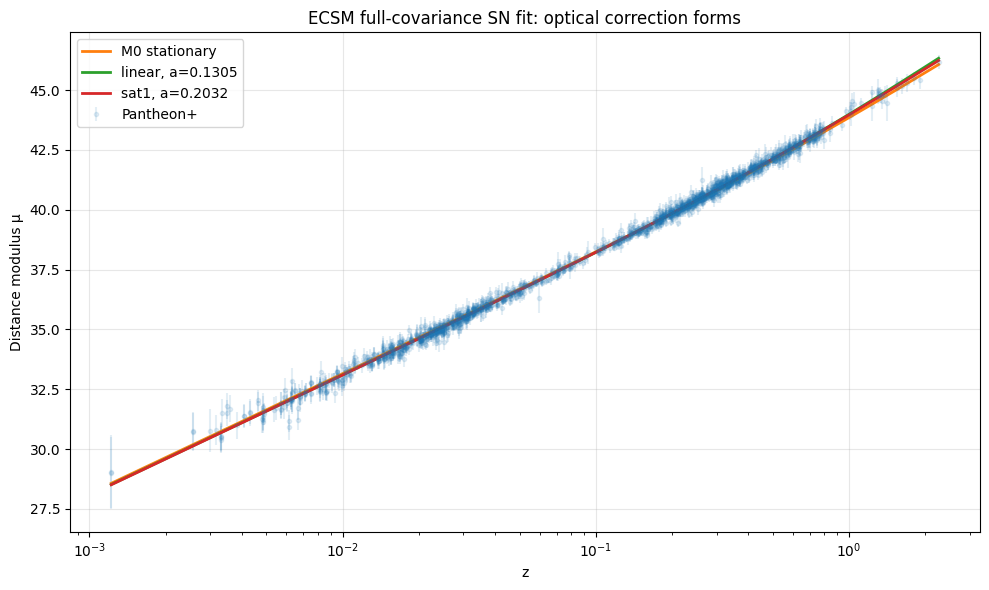

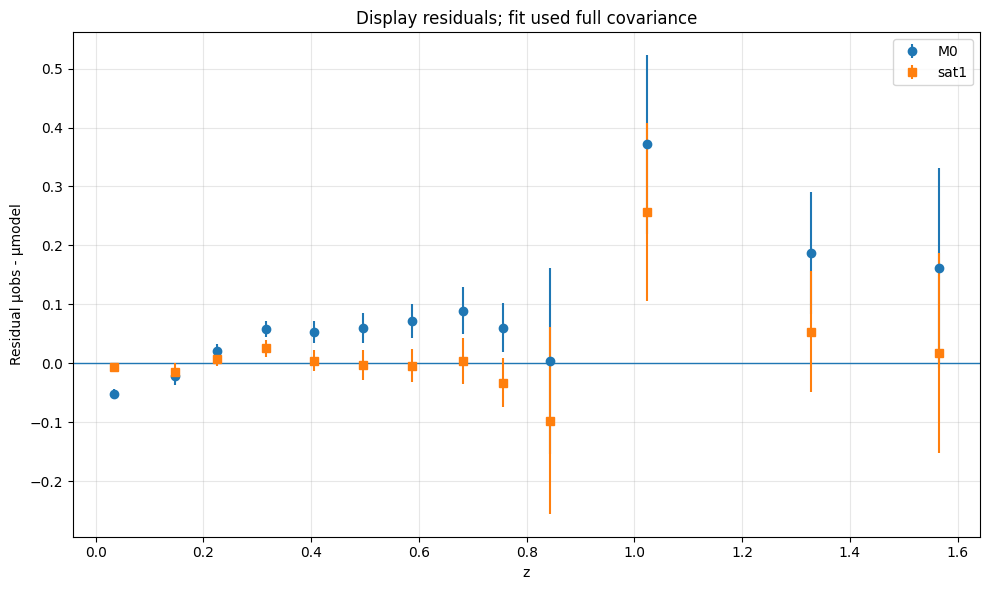

In [ ]:
# ============================================================
# 3. Full-covariance SN test
# ============================================================

def DL_M0(z):
    return (1.0 + np.asarray(z, dtype=float)) * Dz_ecsm(z)

def DL_Mopt_linear(z, a):
    Dz = Dz_ecsm(z)
    return (1.0 + np.asarray(z, dtype=float)) * Dz * (1.0 + a * Dz)

def DL_Mopt_sat1(z, a):
    return DL_shape_ecsm(z, a=a)

mu0_shape = mu_model_from_DL_shape(DL_M0(z_sn))
chi2_M0, C0, resid0 = chi2_cov_sn(mu_obs, mu0_shape)
dof_M0 = len(z_sn) - 1

def obj_sn_linear(a):
    mu_shape = mu_model_from_DL_shape(DL_Mopt_linear(z_sn, a))
    chi2, _, _ = chi2_cov_sn(mu_obs, mu_shape)
    return chi2

res_lin = minimize_scalar(obj_sn_linear, bounds=(-0.75, 2.0), method="bounded")
a_lin = float(res_lin.x)
mu_lin_shape = mu_model_from_DL_shape(DL_Mopt_linear(z_sn, a_lin))
chi2_lin, Clin, resid_lin = chi2_cov_sn(mu_obs, mu_lin_shape)
dof_lin = len(z_sn) - 2

def obj_sn_sat1(a):
    mu_shape = mu_model_from_DL_shape(DL_Mopt_sat1(z_sn, a))
    chi2, _, _ = chi2_cov_sn(mu_obs, mu_shape)
    return chi2

res_sat1 = minimize_scalar(obj_sn_sat1, bounds=(-0.95, 5.0), method="bounded")
a_sat1 = float(res_sat1.x)
mu_sat1_shape = mu_model_from_DL_shape(DL_Mopt_sat1(z_sn, a_sat1))
chi2_sat1, Csat1, resid_sat1 = chi2_cov_sn(mu_obs, mu_sat1_shape)
dof_sat1 = len(z_sn) - 2

mu_locked_shape = mu_model_from_DL_shape(DL_Mopt_sat1(z_sn, a_opt))
chi2_locked, Clocked, resid_locked = chi2_cov_sn(mu_obs, mu_locked_shape)

N_sn = len(z_sn)
def AIC(chi2, k): return chi2 + 2*k
def BIC(chi2, k): return chi2 + np.log(N_sn)*k

sn_summary = pd.DataFrame([
    {"model": "M0 stationary", "chi2": chi2_M0, "dof": dof_M0, "k": 1, "AIC": AIC(chi2_M0,1), "BIC": BIC(chi2_M0,1), "offset": C0, "a": np.nan},
    {"model": "Mopt linear", "chi2": chi2_lin, "dof": dof_lin, "k": 2, "AIC": AIC(chi2_lin,2), "BIC": BIC(chi2_lin,2), "offset": Clin, "a": a_lin},
    {"model": "Mopt sat1", "chi2": chi2_sat1, "dof": dof_sat1, "k": 2, "AIC": AIC(chi2_sat1,2), "BIC": BIC(chi2_sat1,2), "offset": Csat1, "a": a_sat1},
    {"model": "Mopt sat1 locked", "chi2": chi2_locked, "dof": dof_sat1, "k": 2, "AIC": AIC(chi2_locked,2), "BIC": BIC(chi2_locked,2), "offset": Clocked, "a": a_opt},
])
sn_summary["chi2_dof"] = sn_summary["chi2"] / sn_summary["dof"]

print("\n====================================================")
print("ECSM full-covariance SN optical test")
print("====================================================")
display(sn_summary)

print("Key comparisons")
print(f"Δchi2 M0 - linear   = {chi2_M0 - chi2_lin:.3f}")
print(f"Δchi2 M0 - sat1     = {chi2_M0 - chi2_sat1:.3f}")
print(f"Δchi2 linear - sat1 = {chi2_lin - chi2_sat1:.3f}")
print(f"Best saturating a   = {a_sat1:.8f}")
print(f"Locked a_opt        = {a_opt:.8f}")

sn_summary.to_csv(OUTPUT_DIR / "sn_full_covariance_summary.csv", index=False)

def binned_residuals_display(z, resid, sig, nbins=25):
    bins = np.linspace(z.min(), z.max(), nbins + 1)
    zbin, rbin, ebin = [], [], []
    for i in range(nbins):
        m = (z >= bins[i]) & (z < bins[i+1])
        if np.sum(m) < 3:
            continue
        w = 1.0 / sig[m]**2
        zbin.append(np.average(z[m], weights=w))
        rbin.append(np.average(resid[m], weights=w))
        ebin.append(np.sqrt(1.0 / np.sum(w)))
    return np.array(zbin), np.array(rbin), np.array(ebin)

z_grid_sn = np.linspace(z_sn.min(), z_sn.max(), 900)

plt.figure(figsize=(10,6))
plt.errorbar(z_sn, mu_obs, yerr=sig_diag, fmt=".", alpha=0.12, label="Pantheon+")
plt.plot(z_grid_sn, mu_model_from_DL_shape(DL_M0(z_grid_sn)) + C0, lw=2, label="M0 stationary")
plt.plot(z_grid_sn, mu_model_from_DL_shape(DL_Mopt_linear(z_grid_sn, a_lin)) + Clin, lw=2, label=f"linear, a={a_lin:.4f}")
plt.plot(z_grid_sn, mu_model_from_DL_shape(DL_Mopt_sat1(z_grid_sn, a_sat1)) + Csat1, lw=2, label=f"sat1, a={a_sat1:.4f}")
plt.xscale("log")
plt.xlabel("z")
plt.ylabel("Distance modulus μ")
plt.title("ECSM full-covariance SN fit: optical correction forms")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sn_full_covariance_models.png", dpi=200)
plt.show()

zb0, rb0, eb0 = binned_residuals_display(z_sn, resid0, sig_diag)
zbs, rbs, ebs = binned_residuals_display(z_sn, resid_sat1, sig_diag)

plt.figure(figsize=(10,6))
plt.axhline(0, lw=1)
plt.errorbar(zb0, rb0, yerr=eb0, fmt="o", label="M0")
plt.errorbar(zbs, rbs, yerr=ebs, fmt="s", label="sat1")
plt.xlabel("z")
plt.ylabel("Residual μobs - μmodel")
plt.title("Display residuals; fit used full covariance")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sn_full_covariance_residuals.png", dpi=200)
plt.show()

## 4. BAO scale anchor

BAO uses the same locked optical map:

\[
D_M(z)=S_{\rm BAO}D_{\rm opt}(z),
\]

\[
H_{\rm eff}(z)=\frac{c}{S_{\rm BAO}\,dD_{\rm opt}/dz}.
\]

Here \(H_{\rm eff}\) is a radial BAO data-compression proxy, not metric expansion.

BAO dataframe:


,z,DM,Hz,DM_err,Hz_err
0,0.38,1506.32,80.7378,24.785175,2.399863
1,0.51,1976.68,90.7564,26.991109,2.132272
2,0.61,2308.86,98.8572,33.238212,2.238548



BAO scale anchor: ECSM locked a
a_opt        = 0.20319453
S_bao_v2     = 4518.092942
chi2_bao_v2  = 3.660583
n_obs        = 6
dof          = 5
chi2/dof     = 0.732117


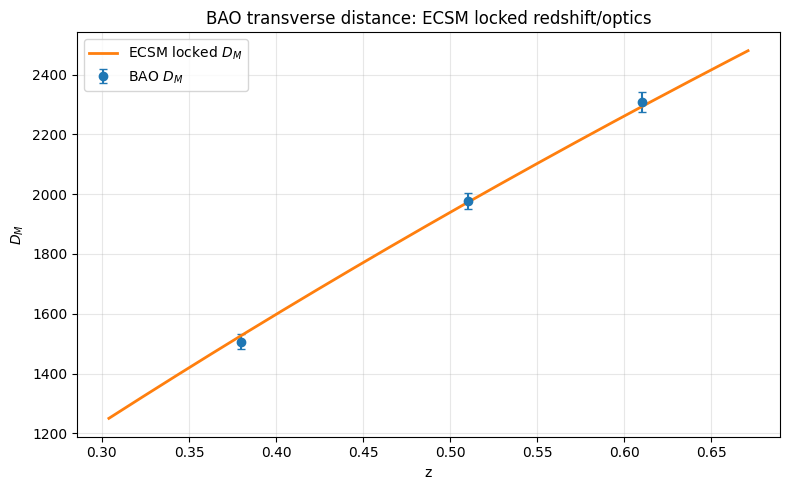

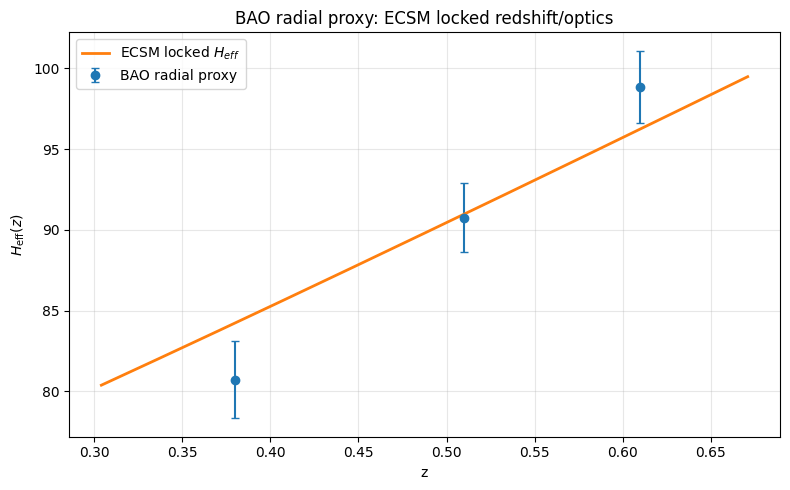

In [ ]:
# ============================================================
# 4. BAO scale anchor
# ============================================================

def load_beutler_results(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing BAO results file: {path}")

    df = pd.read_csv(path, sep=r"\s+", comment="#", header=None,
                     names=["z", "obs", "value"], engine="python")
    df["z"] = pd.to_numeric(df["z"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["z", "value"])
    df["obs_norm"] = df["obs"].astype(str).str.lower()

    rows = []
    for zval, g in df.groupby("z"):
        row = {"z": float(zval)}
        for _, r in g.iterrows():
            obs = r["obs_norm"]
            val = float(r["value"])
            if "dm" in obs or "d_m" in obs:
                row["DM"] = val
            elif "hz" in obs or "h(z)" in obs or obs.startswith("h"):
                row["Hz"] = val
        rows.append(row)

    return pd.DataFrame(rows).sort_values("z").reset_index(drop=True)

bao_df = load_beutler_results(BEUTLER_RES)
bao_df["DM_err"] = np.nan
bao_df["Hz_err"] = np.nan
bao_cov_blocks = {}

for i, cov_path in enumerate(BEUTLER_COVS):
    if Path(cov_path).exists() and i < len(bao_df):
        C = np.loadtxt(cov_path)
        C = np.asarray(C, dtype=float)
        if C.ndim == 1:
            n = int(np.sqrt(C.size))
            C = C.reshape(n, n)
        bao_cov_blocks[i] = C
        if C.shape[0] >= 2:
            bao_df.loc[i, "DM_err"] = np.sqrt(C[0,0])
            bao_df.loc[i, "Hz_err"] = np.sqrt(C[1,1])

print("BAO dataframe:")
display(bao_df)

def bao_chi2_S_a(S, a):
    if not np.isfinite(S) or not np.isfinite(a) or S <= 0:
        return np.inf
    zmax = np.nanmax(bao_df["z"].to_numpy(float))
    Dzmax = np.log1p(zmax)
    if 1.0 + a * Dzmax / (1.0 + Dzmax) <= 0:
        return np.inf

    chi2 = 0.0
    for i, row in bao_df.iterrows():
        z_i = float(row["z"])
        pred_DM = S * DM_shape_ecsm(z_i, a=a)
        pred_Hz = H_eff_ecsm(z_i, S, a=a)
        has_DM = np.isfinite(row.get("DM", np.nan))
        has_Hz = np.isfinite(row.get("Hz", np.nan))

        if has_DM and has_Hz and i in bao_cov_blocks:
            obs_vec = np.array([row["DM"], row["Hz"]], dtype=float)
            pred_vec = np.array([pred_DM, pred_Hz], dtype=float)
            C = np.asarray(bao_cov_blocks[i], dtype=float)
            diff = obs_vec - pred_vec
            try:
                chi2 += diff @ np.linalg.inv(C) @ diff
            except np.linalg.LinAlgError:
                chi2 += np.sum(diff**2 / np.diag(C))
        else:
            if has_DM and np.isfinite(row.get("DM_err", np.nan)) and row["DM_err"] > 0:
                chi2 += ((row["DM"] - pred_DM) / row["DM_err"])**2
            if has_Hz and np.isfinite(row.get("Hz_err", np.nan)) and row["Hz_err"] > 0:
                chi2 += ((row["Hz"] - pred_Hz) / row["Hz_err"])**2
    return float(chi2)

def chi2_profile_S_for_a(a):
    def obj_logS(logS):
        return bao_chi2_S_a(np.exp(logS), a)
    res = minimize_scalar(obj_logS, bounds=(np.log(1000.0), np.log(20000.0)), method="bounded")
    return float(np.exp(res.x)), float(res.fun)

S_bao_v2, chi2_bao_v2 = chi2_profile_S_for_a(a_opt)
n_bao_obs = int(np.isfinite(bao_df.get("DM", np.nan)).sum() + np.isfinite(bao_df.get("Hz", np.nan)).sum())
dof_bao_v2 = n_bao_obs - 1

print("\n==============================")
print("BAO scale anchor: ECSM locked a")
print("==============================")
print(f"a_opt        = {a_opt:.8f}")
print(f"S_bao_v2     = {S_bao_v2:.6f}")
print(f"chi2_bao_v2  = {chi2_bao_v2:.6f}")
print(f"n_obs        = {n_bao_obs}")
print(f"dof          = {dof_bao_v2}")
print(f"chi2/dof     = {chi2_bao_v2/dof_bao_v2:.6f}" if dof_bao_v2 > 0 else "dof unavailable")

zdat = bao_df["z"].to_numpy(float)
zgrid = np.linspace(max(1e-4, zdat.min()*0.8), zdat.max()*1.1, 400)

m = np.isfinite(bao_df["DM"]) & np.isfinite(bao_df["DM_err"]) & (bao_df["DM_err"] > 0)
if m.any():
    plt.figure(figsize=(8,5))
    plt.errorbar(bao_df.loc[m,"z"], bao_df.loc[m,"DM"], yerr=bao_df.loc[m,"DM_err"], fmt="o", capsize=3, label="BAO $D_M$")
    plt.plot(zgrid, S_bao_v2 * DM_shape_ecsm(zgrid, a=a_opt), lw=2, label="ECSM locked $D_M$")
    plt.xlabel("z"); plt.ylabel(r"$D_M$")
    plt.title("BAO transverse distance: ECSM locked redshift/optics")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "bao_dm_ecsm_locked.png", dpi=200)
    plt.show()

m = np.isfinite(bao_df["Hz"]) & np.isfinite(bao_df["Hz_err"]) & (bao_df["Hz_err"] > 0)
if m.any():
    plt.figure(figsize=(8,5))
    plt.errorbar(bao_df.loc[m,"z"], bao_df.loc[m,"Hz"], yerr=bao_df.loc[m,"Hz_err"], fmt="o", capsize=3, label="BAO radial proxy")
    plt.plot(zgrid, H_eff_ecsm(zgrid, S_bao_v2, a=a_opt), lw=2, label="ECSM locked $H_{eff}$")
    plt.xlabel("z"); plt.ylabel(r"$H_{\rm eff}(z)$")
    plt.title("BAO radial proxy: ECSM locked redshift/optics")
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "bao_heff_ecsm_locked.png", dpi=200)
    plt.show()

## 5. BAO-only optical-capacity profile

This test asks whether BAO independently lands near the SN-fixed optical-capacity value. SN fixed \(a\). BAO is then allowed to choose \(a\) and \(S_{\rm BAO}\) freely.


BAO-only optical-capacity test


,case,a,S_bao,chi2,dof,chi2_dof
0,BAO free a,0.179343,4554.132428,3.594726,4,0.898681
1,BAO SN-fixed a,0.203195,4518.092942,3.660583,5,0.732117
2,BAO a=0,0.000000,4845.928284,8.046267,5,1.609253


Key comparisons
Δchi2 a=0 - SN-fixed a       = 4.385685
Δchi2 SN-fixed a - BAO-free  = 0.065857
Difference a_BAO - a_SN      = -0.023852
Profile likelihood for a
approx 1σ a range: (0.09333333333333332, 0.2733333333333334)
approx 2σ a range: (0.010000000000000009, 0.37666666666666665)


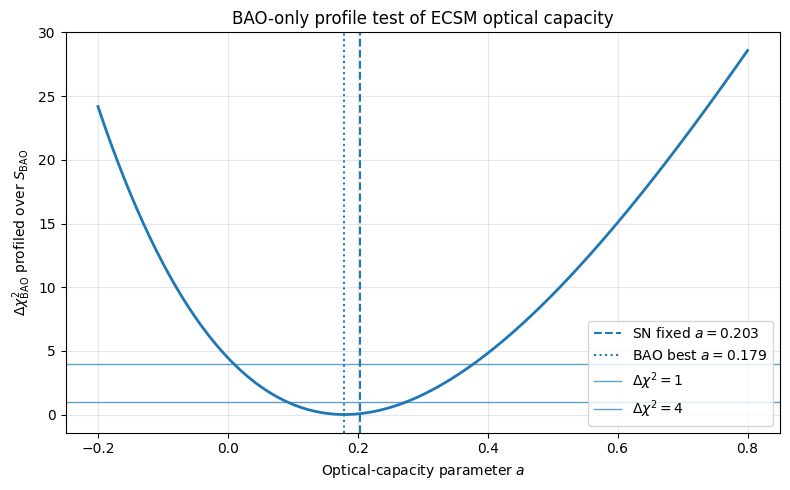

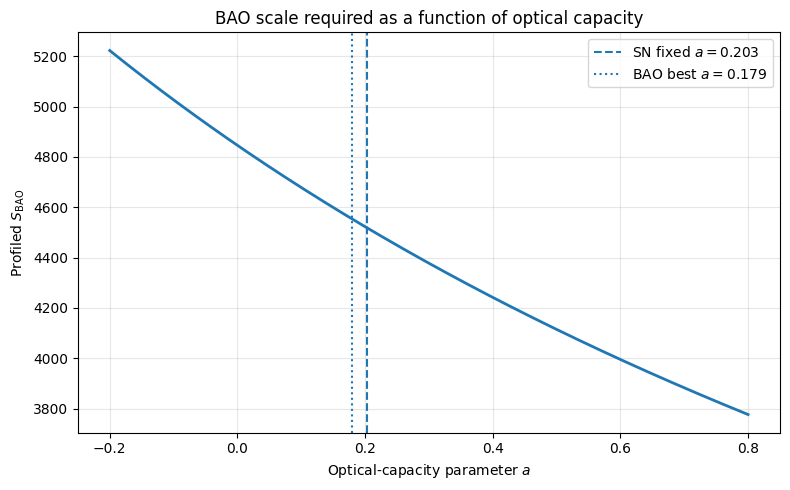

In [ ]:
# ============================================================
# 5. BAO-only optical-capacity profile
# ============================================================

def obj_bao_free(params):
    logS, a = params
    return bao_chi2_S_a(np.exp(logS), a)

x0 = np.array([np.log(S_bao_v2), a_opt])
bounds = [(np.log(1000.0), np.log(20000.0)), (-0.8, 2.0)]
res_free = minimize(obj_bao_free, x0=x0, bounds=bounds, method="L-BFGS-B")

S_bao_free = float(np.exp(res_free.x[0]))
a_bao_free = float(res_free.x[1])
chi2_bao_free = float(res_free.fun)

S_bao_at_SN_a, chi2_bao_at_SN_a = chi2_profile_S_for_a(a_opt)
S_bao_at_a0, chi2_bao_at_a0 = chi2_profile_S_for_a(0.0)

dof_free = n_bao_obs - 2
dof_fixed = n_bao_obs - 1

bao_a_summary = pd.DataFrame({
    "case": ["BAO free a", "BAO SN-fixed a", "BAO a=0"],
    "a": [a_bao_free, a_opt, 0.0],
    "S_bao": [S_bao_free, S_bao_at_SN_a, S_bao_at_a0],
    "chi2": [chi2_bao_free, chi2_bao_at_SN_a, chi2_bao_at_a0],
    "dof": [dof_free, dof_fixed, dof_fixed],
})
bao_a_summary["chi2_dof"] = bao_a_summary["chi2"] / bao_a_summary["dof"]

print("\n====================================================")
print("BAO-only optical-capacity test")
print("====================================================")
display(bao_a_summary)
print("Key comparisons")
print(f"Δchi2 a=0 - SN-fixed a       = {chi2_bao_at_a0 - chi2_bao_at_SN_a:.6f}")
print(f"Δchi2 SN-fixed a - BAO-free  = {chi2_bao_at_SN_a - chi2_bao_free:.6f}")
print(f"Difference a_BAO - a_SN      = {a_bao_free - a_opt:.6f}")

a_grid = np.linspace(-0.2, 0.8, 301)
chi2_profile = []
S_profile = []
for a in a_grid:
    S_i, chi2_i = chi2_profile_S_for_a(a)
    S_profile.append(S_i)
    chi2_profile.append(chi2_i)
chi2_profile = np.array(chi2_profile)
S_profile = np.array(S_profile)
delta_profile = chi2_profile - np.nanmin(chi2_profile)
within_1 = a_grid[delta_profile <= 1.0]
within_4 = a_grid[delta_profile <= 4.0]
a_1sig = (float(within_1.min()), float(within_1.max())) if len(within_1) else (None, None)
a_2sig = (float(within_4.min()), float(within_4.max())) if len(within_4) else (None, None)

print("Profile likelihood for a")
print("approx 1σ a range:", a_1sig)
print("approx 2σ a range:", a_2sig)

bao_a_summary.to_csv(OUTPUT_DIR / "bao_only_a_capacity_summary.csv", index=False)
pd.DataFrame({"a": a_grid, "S_profile": S_profile, "chi2": chi2_profile, "delta_chi2": delta_profile}).to_csv(OUTPUT_DIR / "bao_profile_chi2_vs_a.csv", index=False)

plt.figure(figsize=(8,5))
plt.plot(a_grid, delta_profile, lw=2)
plt.axvline(a_opt, ls="--", label=fr"SN fixed $a={a_opt:.3f}$")
plt.axvline(a_bao_free, ls=":", label=fr"BAO best $a={a_bao_free:.3f}$")
plt.axhline(1.0, lw=1, alpha=0.7, label=r"$\Delta\chi^2=1$")
plt.axhline(4.0, lw=1, alpha=0.7, label=r"$\Delta\chi^2=4$")
plt.xlabel(r"Optical-capacity parameter $a$")
plt.ylabel(r"$\Delta\chi^2_{\rm BAO}$ profiled over $S_{\rm BAO}$")
plt.title("BAO-only profile test of ECSM optical capacity")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bao_profile_chi2_vs_a.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(a_grid, S_profile, lw=2)
plt.axvline(a_opt, ls="--", label=fr"SN fixed $a={a_opt:.3f}$")
plt.axvline(a_bao_free, ls=":", label=fr"BAO best $a={a_bao_free:.3f}$")
plt.xlabel(r"Optical-capacity parameter $a$")
plt.ylabel(r"Profiled $S_{\rm BAO}$")
plt.title("BAO scale required as a function of optical capacity")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bao_profile_S_vs_a.png", dpi=200)
plt.show()

## 6. RSD / growth consistency

This is a minimal effective-growth consistency diagnostic using the BAO-anchored ECSM radial proxy. It is not derived from Friedmann expansion.

Loaded RSD file: /content/drive/MyDrive/rsd_fs8_data.csv


,z,fs8_obs,fs8_err
0,0.020,0.428,0.046
1,0.067,0.423,0.055
2,0.100,0.370,0.130
3,0.150,0.490,0.150
4,0.170,0.510,0.060
5,0.320,0.384,0.095
6,0.380,0.440,0.060
7,0.440,0.413,0.080
8,0.510,0.460,0.050
9,0.570,0.444,0.038



ECSM locked BAO→RSD growth consistency
N RSD      = 15
Om0        = 0.32
sigma8_0   = 0.792894
chi2       = 4.2757
dof        = 14
chi2/dof   = 0.3054
p-value    = 0.9936
rms pull   = 0.5339
max |pull| = 1.0678


,z,fs8_obs,fs8_err,fD_th,sigma8_0,fs8_th,pull
0,0.020,0.428,0.046,0.539064,0.792894,0.427421,0.012587
1,0.067,0.423,0.055,0.548428,0.792894,0.434845,-0.215372
2,0.100,0.370,0.130,0.553778,0.792894,0.439087,-0.531439
3,0.150,0.490,0.150,0.560281,0.792894,0.444244,0.305041
4,0.170,0.510,0.060,0.562412,0.792894,0.445934,1.067773
5,0.320,0.384,0.095,0.571834,0.792894,0.453404,-0.730570
6,0.380,0.440,0.060,0.573111,0.792894,0.454417,-0.240278
7,0.440,0.413,0.080,0.573334,0.792894,0.454593,-0.519918
8,0.510,0.460,0.050,0.572495,0.792894,0.453928,0.121438
9,0.570,0.444,0.038,0.570993,0.792894,0.452737,-0.229932


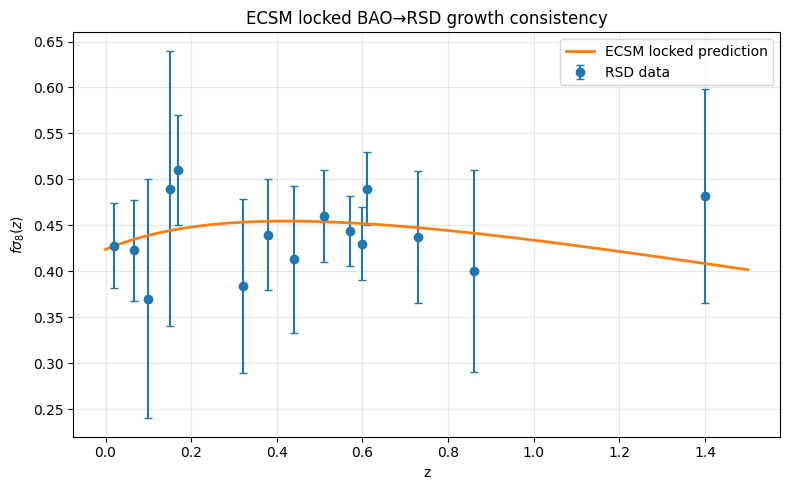

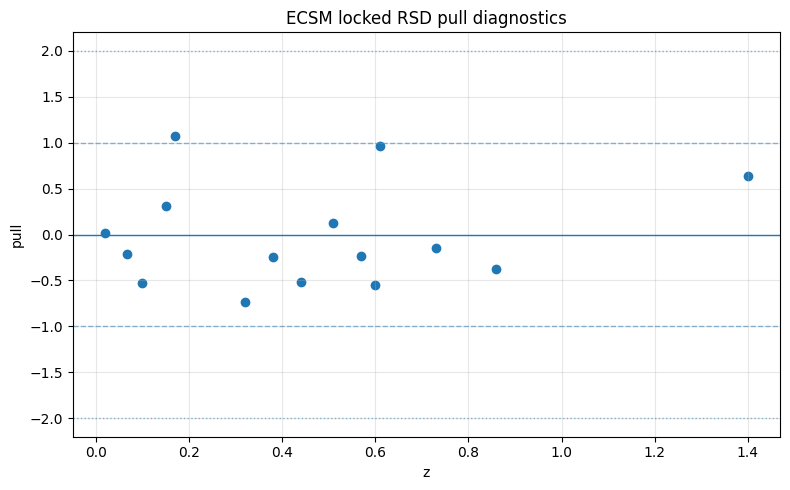

In [ ]:
# ============================================================
# 6. RSD / growth consistency
# ============================================================

def load_rsd_data():
    for p in RSD_CANDIDATES:
        if Path(p).exists():
            df = pd.read_csv(p)
            zc = next((c for c in ["z","redshift"] if c in df.columns), None)
            fc = next((c for c in ["fs8","fσ8","fsigma8","f_sigma8","fs8_obs"] if c in df.columns), None)
            ec = next((c for c in ["err","fs8_err","sigma","sigma_fs8"] if c in df.columns), None)
            if zc and fc and ec:
                out = pd.DataFrame({"z": df[zc].astype(float), "fs8_obs": df[fc].astype(float), "fs8_err": df[ec].astype(float)})
                print("Loaded RSD file:", p)
                return out
    print("No RSD file found; using embedded 15-point compilation from current ECSM diagnostic.")
    return pd.DataFrame({
        "z":       [0.020,0.067,0.100,0.150,0.170,0.320,0.380,0.440,0.510,0.570,0.600,0.610,0.730,0.860,1.400],
        "fs8_obs": [0.428,0.423,0.370,0.490,0.510,0.384,0.440,0.413,0.460,0.444,0.430,0.490,0.437,0.400,0.482],
        "fs8_err": [0.046,0.055,0.130,0.150,0.060,0.095,0.060,0.080,0.050,0.038,0.040,0.040,0.072,0.110,0.116],
    })

rsd_df = load_rsd_data().dropna().sort_values("z").reset_index(drop=True)
display(rsd_df)

def growth_prediction_ecsm(z_eval, Om0=0.32, a=a_opt, S=S_bao_v2):
    z_eval = np.asarray(z_eval, dtype=float)
    zmax = max(3.0, float(np.max(z_eval)) * 1.1)
    z_grid = np.linspace(0.0, zmax, 2500)
    H_eff = H_eff_ecsm(z_grid, S, a=a)
    H0_eff = H_eff_ecsm(0.0, S, a=a)
    E = H_eff / H0_eff
    Omz = Om0 * (1.0 + z_grid)**3 / (E**2)
    Omz = np.clip(Omz, 1e-6, 5.0)
    gamma = 0.55
    f = np.clip(Omz, 1e-6, 5.0)**gamma
    lnD = cumulative_trapezoid(-f/(1.0+z_grid), z_grid, initial=0.0)
    D = np.exp(lnD)
    return np.interp(z_eval, z_grid, f) * np.interp(z_eval, z_grid, D)

Om0_rsd = 0.32
fD_th = growth_prediction_ecsm(rsd_df["z"].to_numpy(float), Om0=Om0_rsd, a=a_opt, S=S_bao_v2)
w = 1.0 / rsd_df["fs8_err"].to_numpy(float)**2
y = rsd_df["fs8_obs"].to_numpy(float)
sigma8_0_best = float(np.sum(w * y * fD_th) / np.sum(w * fD_th**2))
fs8_th = sigma8_0_best * fD_th
pull = (y - fs8_th) / rsd_df["fs8_err"].to_numpy(float)
chi2_rsd = float(np.sum(pull**2))
dof_rsd = len(rsd_df) - 1
p_value_rsd = float(1.0 - chi2_dist.cdf(chi2_rsd, dof_rsd))

rsd_fit_v2 = rsd_df.copy()
rsd_fit_v2["fD_th"] = fD_th
rsd_fit_v2["sigma8_0"] = sigma8_0_best
rsd_fit_v2["fs8_th"] = fs8_th
rsd_fit_v2["pull"] = pull

print("\n====================================================")
print("ECSM locked BAO→RSD growth consistency")
print("====================================================")
print(f"N RSD      = {len(rsd_df)}")
print(f"Om0        = {Om0_rsd}")
print(f"sigma8_0   = {sigma8_0_best:.6f}")
print(f"chi2       = {chi2_rsd:.4f}")
print(f"dof        = {dof_rsd}")
print(f"chi2/dof   = {chi2_rsd/dof_rsd:.4f}")
print(f"p-value    = {p_value_rsd:.4f}")
print(f"rms pull   = {np.sqrt(np.mean(pull**2)):.4f}")
print(f"max |pull| = {np.max(np.abs(pull)):.4f}")
display(rsd_fit_v2)

rsd_fit_v2.to_csv(OUTPUT_DIR / "rsd_fit_ecsm_locked.csv", index=False)

zgrid_rsd = np.linspace(0.0, max(1.5, rsd_df["z"].max()*1.05), 400)
fs8_grid = sigma8_0_best * growth_prediction_ecsm(zgrid_rsd, Om0=Om0_rsd, a=a_opt, S=S_bao_v2)

plt.figure(figsize=(8,5))
plt.errorbar(rsd_df["z"], rsd_df["fs8_obs"], yerr=rsd_df["fs8_err"], fmt="o", capsize=3, label="RSD data")
plt.plot(zgrid_rsd, fs8_grid, lw=2, label="ECSM locked prediction")
plt.xlabel("z"); plt.ylabel(r"$f\sigma_8(z)$")
plt.title("ECSM locked BAO→RSD growth consistency")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rsd_growth_ecsm_locked.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
plt.axhline(0, lw=1)
plt.axhline(1, lw=1, ls="--", alpha=0.5)
plt.axhline(-1, lw=1, ls="--", alpha=0.5)
plt.axhline(2, lw=1, ls=":", alpha=0.5)
plt.axhline(-2, lw=1, ls=":", alpha=0.5)
plt.scatter(rsd_df["z"], pull)
plt.xlabel("z"); plt.ylabel("pull")
plt.title("ECSM locked RSD pull diagnostics")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rsd_pulls_ecsm_locked.png", dpi=200)
plt.show()

## 7. Optical-capacity diagnostics

ECSM optical-capacity diagnostics
Adopted a_opt = 0.20319453
Saturated Dopt/Dz limit = 1.203195
Saturated beam-area multiplier ≈ (1+a)^2 = 1.447677


,z,Dz_ln1pz,B_capacity,Dopt_over_Dz,area_multiplier_approx,eta_distance_duality
0,0.10000,0.095310,0.087017,1.017681,1.035675,1.0
1,0.50000,0.405465,0.288492,1.058620,1.120676,1.0
2,1.00000,0.693147,0.409384,1.083185,1.173289,1.0
3,1.50000,0.916291,0.478159,1.097159,1.203758,1.0
4,2.00000,1.098612,0.523495,1.106371,1.224057,1.0
5,2.26137,1.182147,0.541736,1.110078,1.232273,1.0
6,3.00000,1.386294,0.580940,1.118044,1.250022,1.0


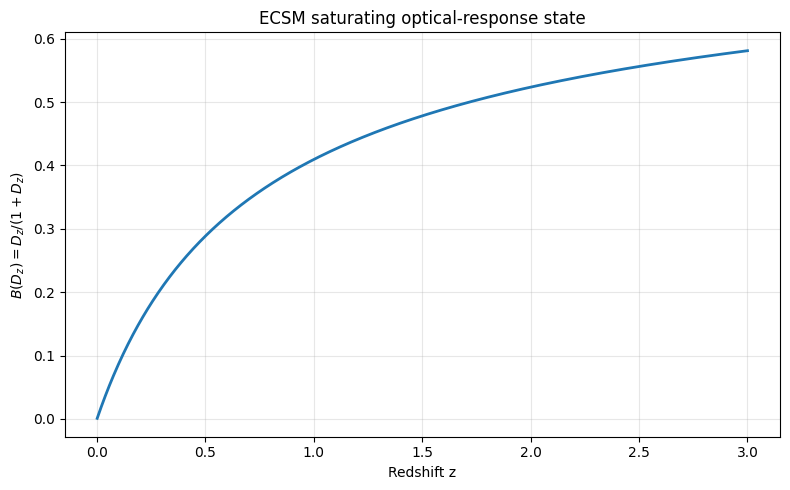

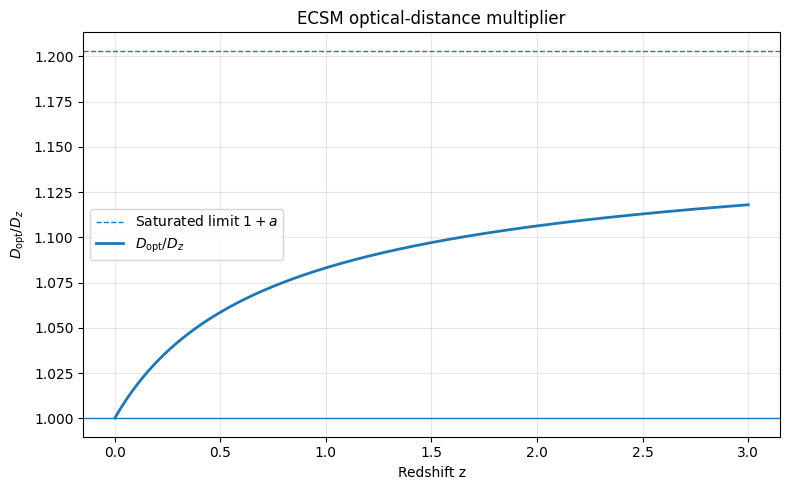

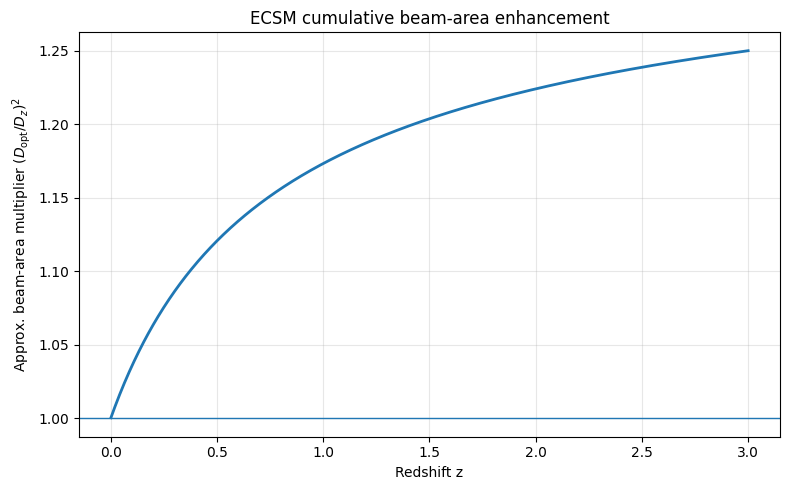

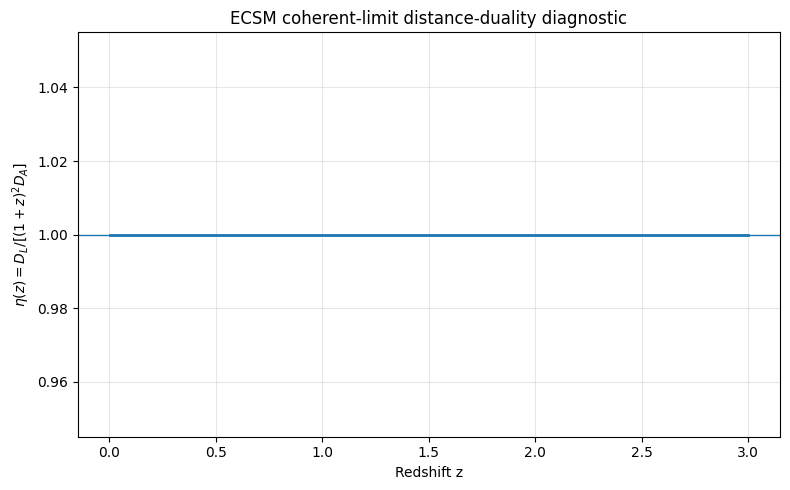

In [ ]:
# ============================================================
# 7. Optical-capacity diagnostics
# ============================================================

z_check = np.array([0.1, 0.5, 1.0, 1.5, 2.0, 2.26137, 3.0])
diagnostics = pd.DataFrame({
    "z": z_check,
    "Dz_ln1pz": Dz_ecsm(z_check),
    "B_capacity": B_capacity(z_check),
    "Dopt_over_Dz": optical_multiplier(z_check, a=a_opt),
    "area_multiplier_approx": optical_multiplier(z_check, a=a_opt)**2,
    "eta_distance_duality": distance_duality_eta(z_check, a=a_opt),
})

print("ECSM optical-capacity diagnostics")
print(f"Adopted a_opt = {a_opt:.8f}")
print(f"Saturated Dopt/Dz limit = {1+a_opt:.6f}")
print(f"Saturated beam-area multiplier ≈ (1+a)^2 = {(1+a_opt)**2:.6f}")
display(diagnostics)

diagnostics.to_csv(OUTPUT_DIR / "ecsm_optical_capacity_diagnostics.csv", index=False)

z_grid = np.linspace(0.001, 3.0, 800)
B_grid = B_capacity(z_grid)
M_grid = optical_multiplier(z_grid, a=a_opt)
eta_grid = distance_duality_eta(z_grid, a=a_opt)

plt.figure(figsize=(8,5))
plt.plot(z_grid, B_grid, lw=2)
plt.xlabel("Redshift z")
plt.ylabel(r"$B(D_z)=D_z/(1+D_z)$")
plt.title("ECSM saturating optical-response state")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecsm_B_capacity_vs_z.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
plt.axhline(1.0, lw=1)
plt.axhline(1.0 + a_opt, lw=1, ls="--", label=r"Saturated limit $1+a$")
plt.plot(z_grid, M_grid, lw=2, label=r"$D_{\rm opt}/D_z$")
plt.xlabel("Redshift z")
plt.ylabel(r"$D_{\rm opt}/D_z$")
plt.title("ECSM optical-distance multiplier")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecsm_optical_multiplier_vs_z.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
plt.axhline(1.0, lw=1)
plt.plot(z_grid, M_grid**2, lw=2)
plt.xlabel("Redshift z")
plt.ylabel(r"Approx. beam-area multiplier $(D_{\rm opt}/D_z)^2$")
plt.title("ECSM cumulative beam-area enhancement")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecsm_beam_area_multiplier_vs_z.png", dpi=200)
plt.show()

plt.figure(figsize=(8,5))
plt.axhline(1.0, lw=1)
plt.plot(z_grid, eta_grid, lw=2)
plt.xlabel("Redshift z")
plt.ylabel(r"$\eta(z)=D_L/[(1+z)^2D_A]$")
plt.title("ECSM coherent-limit distance-duality diagnostic")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ecsm_distance_duality_eta.png", dpi=200)
plt.show()

## 8. Flat-\(\Lambda\)CDM baseline comparison

This baseline is included to compare the locked ECSM closure against a conventional expansion-based fit on the same compressed datasets. It is a reference model for \(\chi^2\), not an ontology assumption inside ECSM.

In [ ]:
# ============================================================
# 13a. Ensure SN full-covariance variables exist for ΛCDM comparison
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.linalg import cho_factor, cho_solve

DATA_PATH = Path("/content/drive/MyDrive/PantheonPlus/Pantheon+SH0ES.dat")
COV_PATH  = Path("/content/drive/MyDrive/PantheonPlus/Pantheon+SH0ES_STAT+SYS.cov")

if "z" not in globals() or "mu_obs" not in globals() or "Cinv_dot" not in globals():

    print("Loading Pantheon+ SN data/covariance for ΛCDM comparison...")

    # ------------------------------------------------------------
    # Load Pantheon+ table
    # ------------------------------------------------------------
    df_sn = pd.read_csv(DATA_PATH, sep=r"\s+", comment="#")

    z_col = "zHD" if "zHD" in df_sn.columns else "z"
    mu_col = "MU_SH0ES" if "MU_SH0ES" in df_sn.columns else "MU"
    sig_col = "MU_SH0ES_ERR_DIAG" if "MU_SH0ES_ERR_DIAG" in df_sn.columns else None

    z_raw = df_sn[z_col].to_numpy(float)
    mu_raw = df_sn[mu_col].to_numpy(float)

    if sig_col is not None:
        sig_raw = df_sn[sig_col].to_numpy(float)
    else:
        sig_raw = np.ones(len(df_sn))

    sn_mask = (
        np.isfinite(z_raw)
        & np.isfinite(mu_raw)
        & np.isfinite(sig_raw)
        & (z_raw > 0)
        & (sig_raw > 0)
    )

    z = z_raw[sn_mask]
    mu_obs = mu_raw[sn_mask]
    sig_diag = sig_raw[sn_mask]

    print(f"Loaded SN rows: {len(z)}")
    print(f"z range: {z.min()} to {z.max()}")

    # ------------------------------------------------------------
    # Load covariance
    # ------------------------------------------------------------
    raw = np.loadtxt(COV_PATH)
    flat = raw.ravel()

    first = int(round(flat[0]))

    if first * first == len(flat) - 1:
        n_cov = first
        C = flat[1:].reshape(n_cov, n_cov)
    elif int(round(np.sqrt(len(flat)))) ** 2 == len(flat):
        n_cov = int(round(np.sqrt(len(flat))))
        C = flat.reshape(n_cov, n_cov)
    elif raw.ndim == 2 and raw.shape[0] == raw.shape[1]:
        C = raw
        n_cov = C.shape[0]
    else:
        raise ValueError(f"Could not parse covariance file. raw shape={raw.shape}")

    if C.shape[0] != len(z):
        if C.shape[0] == len(sn_mask):
            C = C[np.ix_(sn_mask, sn_mask)]
            print("Applied SN mask to covariance.")
        else:
            raise ValueError(
                f"Covariance size {C.shape[0]} does not match SN count {len(z)}."
            )

    C = 0.5 * (C + C.T)

    cho = cho_factor(C, lower=True, check_finite=False)

    def Cinv_dot(x):
        return cho_solve(cho, x, check_finite=False)

    print("SN covariance loaded and Cinv_dot created.")

else:
    print("SN full-covariance variables already exist.")

Loading Pantheon+ SN data/covariance for ΛCDM comparison...
Loaded SN rows: 1701
z range: 0.00122 to 2.26137
SN covariance loaded and Cinv_dot created.



Hardened flat LambdaCDM baseline comparison

SN LCDM optimizer:
success-ish      = True
Om_lcdm_sn       = 0.36120389
chi2_lcdm_sn     = 1752.511769
dof_lcdm_sn      = 1699
chi2/dof         = 1.031496

BAO LCDM optimizer:
success          = True
message          = CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Om_lcdm_bao      = 0.34899131
S_lcdm_bao       = 4479.281890
chi2_lcdm_bao    = 2.518127
dof_lcdm_bao     = 4
chi2/dof         = 0.629532

RSD LCDM baseline:
Om from BAO      = 0.34899131
sigma8_lcdm      = 0.764351
chi2_lcdm_rsd    = 5.023511
dof_lcdm_rsd     = 14
chi2/dof         = 0.358822

RSD-only LCDM diagnostic:
Om_lcdm_rsd_free = 0.31845513
sigma8_free      = 0.781725
chi2             = 4.860960


,sector,model,chi2,dof,primary_params,chi2_dof
0,SN full covariance,ECSM locked sat optical,1750.045380,1699,a=0.203195 + offset,1.030044
1,SN full covariance,flat LCDM,1752.511769,1699,Om=0.361204 + offset,1.031496
2,BAO,ECSM locked sat optical,3.660583,5,"a fixed=0.203, S=4518.09",0.732117
3,BAO,flat LCDM,2.518127,4,"Om=0.348991, S=4479.28",0.629532
4,RSD,ECSM BAO-anchored,4.275702,14,"Om=0.32, sigma8=0.7929",0.305407
5,RSD,flat LCDM BAO-anchored,5.023511,14,"Om_BAO=0.348991, sigma8=0.7644",0.358822
6,RSD diagnostic,flat LCDM RSD-only,4.860960,13,"Om=0.318455, sigma8=0.7817",0.373920



Plot offsets:
ECSM SN offset = 43.079282
LCDM SN offset = 43.072259


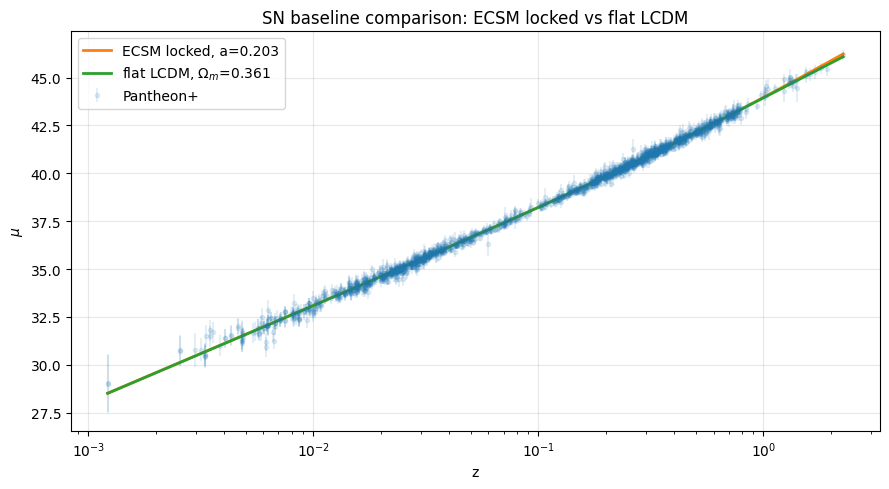

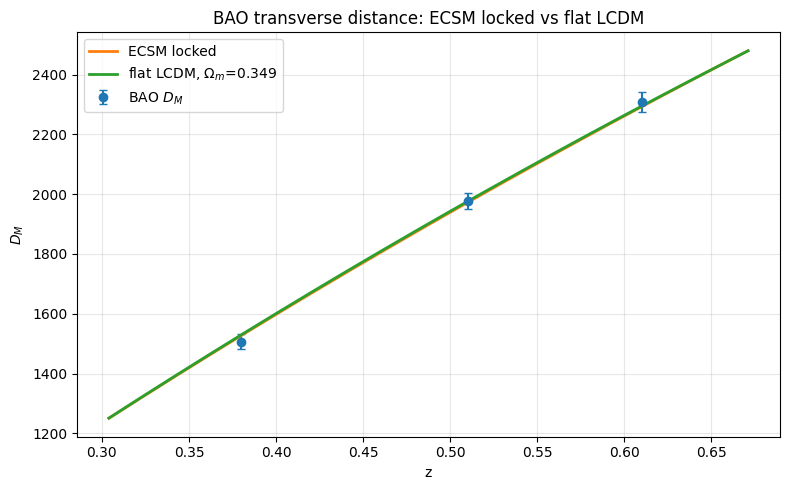

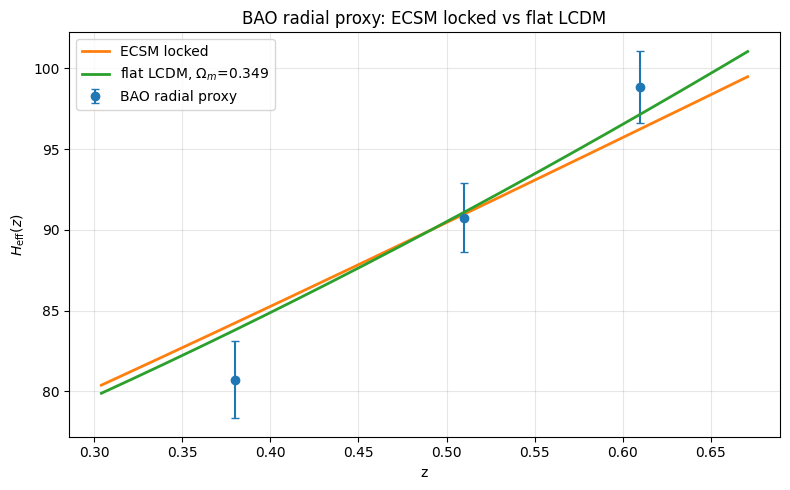

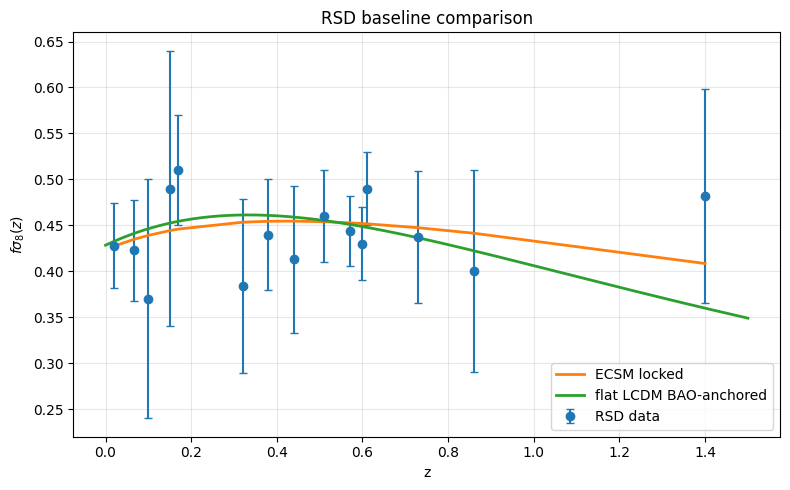

In [ ]:
# ============================================================
# 13. Hardened flat-LambdaCDM baseline comparison
# ============================================================
#
# Purpose:
#   Provide a fair baseline comparison against flat LambdaCDM
#   using the same SN, BAO, and RSD data already loaded.
#
# Fits:
#   SN:
#       flat LCDM with free Omega_m and magnitude offset
#
#   BAO:
#       flat LCDM distance shape with free Omega_m and scale S
#
#   RSD:
#       flat LCDM growth-shape proxy with fixed Omega_m from BAO/SN
#       and fitted sigma8_0
#
# Notes:
#   This is still a compact baseline, not a full Boltzmann-chain
#   cosmological parameter analysis.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar, minimize
from scipy.integrate import cumulative_trapezoid
from pathlib import Path

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

c_kms = 299792.458

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required = ["z", "mu_obs", "Cinv_dot", "bao_df", "bao_cov_blocks", "rsd_df"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Missing variables required for LCDM comparison: {missing}")

# ------------------------------------------------------------
# Flat LCDM distance functions
# Dimensionless comoving distance:
#   X(z) = int_0^z dz'/E(z')
# with E(z)=sqrt(Om(1+z)^3 + 1-Om)
#
# Absolute scale is absorbed into SN offset or BAO S.
# ------------------------------------------------------------

def E_lcdm(z, Om):
    z = np.asarray(z, dtype=float)
    if not np.isfinite(Om) or Om <= 0.0 or Om >= 1.0:
        return np.full_like(z, np.nan)
    return np.sqrt(Om * (1.0 + z)**3 + (1.0 - Om))

def lcdm_comoving_shape(z_eval, Om, ngrid=6000):
    """
    Dimensionless comoving distance shape X(z)=int dz/E(z).
    Uses a dense grid and interpolation for stable repeated calls.
    """
    z_eval = np.asarray(z_eval, dtype=float)

    if not np.isfinite(Om) or Om <= 0.0 or Om >= 1.0:
        return np.full_like(z_eval, np.nan)

    zmax = float(np.nanmax(z_eval))
    if zmax <= 0:
        return np.zeros_like(z_eval)

    zgrid = np.linspace(0.0, zmax * 1.0001 + 1e-8, ngrid)
    Ez = E_lcdm(zgrid, Om)

    if np.any(~np.isfinite(Ez)) or np.any(Ez <= 0):
        return np.full_like(z_eval, np.nan)

    integ = cumulative_trapezoid(1.0 / Ez, zgrid, initial=0.0)
    return np.interp(z_eval, zgrid, integ)

def DL_lcdm_shape(z_eval, Om):
    X = lcdm_comoving_shape(z_eval, Om)
    return (1.0 + np.asarray(z_eval, dtype=float)) * X

def DM_lcdm_shape(z_eval, Om):
    return lcdm_comoving_shape(z_eval, Om)

def dDM_dz_lcdm(z_eval, Om):
    Ez = E_lcdm(z_eval, Om)
    return 1.0 / Ez

def H_eff_lcdm_shape(z_eval, S, Om):
    """
    BAO radial proxy using distance slope:
        Dphys = S * X(z)
        H_eff = c / [S dX/dz] = c E(z)/S
    """
    return c_kms / (S * dDM_dz_lcdm(z_eval, Om))


# ============================================================
# SN full-covariance LCDM fit
# ============================================================

ones_lcdm = np.ones(len(z))
Cinv_ones_lcdm = Cinv_dot(ones_lcdm)
one_Cinv_one_lcdm = ones_lcdm @ Cinv_ones_lcdm

def best_offset_cov_lcdm(mu_obs, mu_shape):
    r0 = mu_obs - mu_shape
    return (ones_lcdm @ Cinv_dot(r0)) / one_Cinv_one_lcdm

def chi2_sn_lcdm_for_Om(Om):
    DL = DL_lcdm_shape(z, Om)

    if np.any(DL <= 0) or np.any(~np.isfinite(DL)):
        return np.inf

    mu_shape = 5.0 * np.log10(DL)
    offset = best_offset_cov_lcdm(mu_obs, mu_shape)
    resid = mu_obs - (mu_shape + offset)
    chi2 = resid @ Cinv_dot(resid)

    if not np.isfinite(chi2):
        return np.inf

    return float(chi2)

res_sn_lcdm = minimize_scalar(
    chi2_sn_lcdm_for_Om,
    bounds=(0.05, 0.95),
    method="bounded",
    options={"xatol": 1e-8},
)

Om_lcdm_sn = float(res_sn_lcdm.x)
chi2_lcdm_sn = float(res_sn_lcdm.fun)

DL_sn_best = DL_lcdm_shape(z, Om_lcdm_sn)
mu_lcdm_shape = 5.0 * np.log10(DL_sn_best)
offset_lcdm_sn = best_offset_cov_lcdm(mu_obs, mu_lcdm_shape)

dof_lcdm_sn = len(z) - 2  # Om + offset


# ============================================================
# BAO LCDM fit: free Om and S
# ============================================================

def bao_chi2_lcdm(Om, S):
    if (
        not np.isfinite(Om)
        or not np.isfinite(S)
        or Om <= 0.0
        or Om >= 1.0
        or S <= 0.0
    ):
        return np.inf

    chi2 = 0.0

    for i, row in bao_df.iterrows():
        z_i = float(row["z"])

        pred_DM = S * DM_lcdm_shape(np.array([z_i]), Om)[0]
        pred_Hz = H_eff_lcdm_shape(np.array([z_i]), S, Om)[0]

        has_DM = np.isfinite(row.get("DM", np.nan))
        has_Hz = np.isfinite(row.get("Hz", np.nan))

        if has_DM and has_Hz and i in bao_cov_blocks:
            obs_vec = np.array([row["DM"], row["Hz"]], dtype=float)
            pred_vec = np.array([pred_DM, pred_Hz], dtype=float)
            C = np.asarray(bao_cov_blocks[i], dtype=float)

            if C.ndim == 1:
                n = int(np.sqrt(C.size))
                C = C.reshape(n, n)

            diff = obs_vec - pred_vec

            try:
                chi2 += diff @ np.linalg.inv(C) @ diff
            except np.linalg.LinAlgError:
                diag = np.diag(C)
                chi2 += np.sum(diff**2 / diag)

        else:
            if has_DM and np.isfinite(row.get("DM_err", np.nan)) and row["DM_err"] > 0:
                chi2 += ((row["DM"] - pred_DM) / row["DM_err"])**2

            if has_Hz and np.isfinite(row.get("Hz_err", np.nan)) and row["Hz_err"] > 0:
                chi2 += ((row["Hz"] - pred_Hz) / row["Hz_err"])**2

    return float(chi2)

def obj_bao_lcdm(params):
    Om, logS = params
    S = np.exp(logS)
    return bao_chi2_lcdm(Om, S)

# Multiple starting points to avoid false stuck results
starts = [
    [0.20, np.log(4300.0)],
    [0.25, np.log(4500.0)],
    [0.30, np.log(4500.0)],
    [0.35, np.log(4700.0)],
    [0.40, np.log(5000.0)],
]

best_res = None
for x0 in starts:
    res = minimize(
        obj_bao_lcdm,
        x0=np.array(x0, dtype=float),
        bounds=[(0.05, 0.95), (np.log(500.0), np.log(20000.0))],
        method="L-BFGS-B",
    )

    if best_res is None or res.fun < best_res.fun:
        best_res = res

Om_lcdm_bao = float(best_res.x[0])
S_lcdm_bao = float(np.exp(best_res.x[1]))
chi2_lcdm_bao = float(best_res.fun)

n_bao_obs_lcdm = int(
    np.isfinite(bao_df.get("DM", np.nan)).sum()
    + np.isfinite(bao_df.get("Hz", np.nan)).sum()
)
dof_lcdm_bao = n_bao_obs_lcdm - 2  # Om + S


# ============================================================
# RSD LCDM baseline
# ============================================================
#
# Compact growth-shape proxy:
#   f(z) ≈ Om(z)^gamma, gamma=0.55
#   Dg(z) normalized to 1 at z=0 using d ln D / d ln a = f
#   fσ8(z) = sigma8_0 * f(z) * Dg(z)
#
# Fit sigma8_0 analytically for chosen Om.
# Use Om from BAO fit by default because RSD follows BAO-anchored geometry.
# ============================================================

def Om_z_lcdm(z_eval, Om0):
    z_eval = np.asarray(z_eval, dtype=float)
    Ez2 = Om0 * (1.0 + z_eval)**3 + (1.0 - Om0)
    return Om0 * (1.0 + z_eval)**3 / Ez2

def growth_shape_lcdm(z_eval, Om0, gamma=0.55):
    """
    Returns f(z)*D(z), with D(0)=1.
    """
    z_eval = np.asarray(z_eval, dtype=float)

    zmax = max(float(np.nanmax(z_eval)) * 1.05, 0.01)
    zg = np.linspace(0.0, zmax, 3000)

    fz = Om_z_lcdm(zg, Om0)**gamma

    # d ln D / dz = - f/(1+z)
    integrand = fz / (1.0 + zg)
    I = cumulative_trapezoid(integrand, zg, initial=0.0)

    Dg = np.exp(-I)
    fD_grid = fz * Dg

    return np.interp(z_eval, zg, fD_grid)

def fit_sigma8_for_growth_shape(fD, obs, err):
    w = 1.0 / err**2
    return np.sum(w * obs * fD) / np.sum(w * fD**2)

def rsd_chi2_lcdm_for_Om(Om0):
    z_r = rsd_df["z"].to_numpy(float)
    obs = rsd_df["fs8_obs"].to_numpy(float)
    err = rsd_df["fs8_err"].to_numpy(float)

    fD = growth_shape_lcdm(z_r, Om0)
    sigma8 = fit_sigma8_for_growth_shape(fD, obs, err)
    pred = sigma8 * fD
    pulls = (obs - pred) / err
    chi2 = float(np.sum(pulls**2))

    return chi2, sigma8, pred, pulls

# Use BAO-best Om for locked BAO-anchored LCDM RSD baseline
chi2_lcdm_rsd, sigma8_lcdm, fs8_lcdm_pred, pulls_lcdm_rsd = rsd_chi2_lcdm_for_Om(Om_lcdm_bao)
dof_lcdm_rsd = len(rsd_df) - 1  # sigma8 fitted; Om fixed from BAO

# Optional RSD-only Om profile for diagnostic
def obj_rsd_lcdm_Om(Om):
    chi2, _, _, _ = rsd_chi2_lcdm_for_Om(Om)
    return chi2

res_rsd_lcdm_free = minimize_scalar(
    obj_rsd_lcdm_Om,
    bounds=(0.05, 0.95),
    method="bounded",
)

Om_lcdm_rsd_free = float(res_rsd_lcdm_free.x)
chi2_lcdm_rsd_free, sigma8_lcdm_rsd_free, _, _ = rsd_chi2_lcdm_for_Om(Om_lcdm_rsd_free)


# ============================================================
# Build comparison table
# ============================================================

comparison_summary = pd.DataFrame([
    {
        "sector": "SN full covariance",
        "model": "ECSM locked sat optical",
        "chi2": float(chi2_sat1),
        "dof": int(1699),
        "primary_params": f"a={a_opt:.6f} + offset",
        "chi2_dof": float(chi2_sat1 / 1699),
    },
    {
        "sector": "SN full covariance",
        "model": "flat LCDM",
        "chi2": chi2_lcdm_sn,
        "dof": int(dof_lcdm_sn),
        "primary_params": f"Om={Om_lcdm_sn:.6f} + offset",
        "chi2_dof": chi2_lcdm_sn / dof_lcdm_sn,
    },
    {
        "sector": "BAO",
        "model": "ECSM locked sat optical",
        "chi2": float(chi2_bao_v2),
        "dof": int(dof_bao_v2),
        "primary_params": f"a fixed={a_opt:.3f}, S={S_bao_v2:.2f}",
        "chi2_dof": float(chi2_bao_v2 / dof_bao_v2),
    },
    {
        "sector": "BAO",
        "model": "flat LCDM",
        "chi2": chi2_lcdm_bao,
        "dof": int(dof_lcdm_bao),
        "primary_params": f"Om={Om_lcdm_bao:.6f}, S={S_lcdm_bao:.2f}",
        "chi2_dof": chi2_lcdm_bao / dof_lcdm_bao,
    },
    {
        "sector": "RSD",
        "model": "ECSM BAO-anchored",
        "chi2": float(chi2_rsd),
        "dof": int(dof_rsd),
        "primary_params": f"Om=0.32, sigma8={sigma8_0_best:.4f}",
        "chi2_dof": float(chi2_rsd / dof_rsd),
    },
    {
        "sector": "RSD",
        "model": "flat LCDM BAO-anchored",
        "chi2": chi2_lcdm_rsd,
        "dof": int(dof_lcdm_rsd),
        "primary_params": f"Om_BAO={Om_lcdm_bao:.6f}, sigma8={sigma8_lcdm:.4f}",
        "chi2_dof": chi2_lcdm_rsd / dof_lcdm_rsd,
    },
    {
        "sector": "RSD diagnostic",
        "model": "flat LCDM RSD-only",
        "chi2": chi2_lcdm_rsd_free,
        "dof": int(len(rsd_df) - 2),
        "primary_params": f"Om={Om_lcdm_rsd_free:.6f}, sigma8={sigma8_lcdm_rsd_free:.4f}",
        "chi2_dof": chi2_lcdm_rsd_free / (len(rsd_df) - 2),
    },
])

print("\n====================================================")
print("Hardened flat LambdaCDM baseline comparison")
print("====================================================")

print("\nSN LCDM optimizer:")
print(f"success-ish      = {np.isfinite(chi2_lcdm_sn)}")
print(f"Om_lcdm_sn       = {Om_lcdm_sn:.8f}")
print(f"chi2_lcdm_sn     = {chi2_lcdm_sn:.6f}")
print(f"dof_lcdm_sn      = {dof_lcdm_sn}")
print(f"chi2/dof         = {chi2_lcdm_sn/dof_lcdm_sn:.6f}")

print("\nBAO LCDM optimizer:")
print(f"success          = {best_res.success}")
print(f"message          = {best_res.message}")
print(f"Om_lcdm_bao      = {Om_lcdm_bao:.8f}")
print(f"S_lcdm_bao       = {S_lcdm_bao:.6f}")
print(f"chi2_lcdm_bao    = {chi2_lcdm_bao:.6f}")
print(f"dof_lcdm_bao     = {dof_lcdm_bao}")
print(f"chi2/dof         = {chi2_lcdm_bao/dof_lcdm_bao:.6f}")

print("\nRSD LCDM baseline:")
print(f"Om from BAO      = {Om_lcdm_bao:.8f}")
print(f"sigma8_lcdm      = {sigma8_lcdm:.6f}")
print(f"chi2_lcdm_rsd    = {chi2_lcdm_rsd:.6f}")
print(f"dof_lcdm_rsd     = {dof_lcdm_rsd}")
print(f"chi2/dof         = {chi2_lcdm_rsd/dof_lcdm_rsd:.6f}")

print("\nRSD-only LCDM diagnostic:")
print(f"Om_lcdm_rsd_free = {Om_lcdm_rsd_free:.8f}")
print(f"sigma8_free      = {sigma8_lcdm_rsd_free:.6f}")
print(f"chi2             = {chi2_lcdm_rsd_free:.6f}")

display(comparison_summary)

comparison_summary.to_csv(OUTPUT_DIR / "hardened_lcdm_comparison_summary.csv", index=False)


# ============================================================
# Plots
# ============================================================

# ------------------------------------------------------------
# Helper: safely recover/recompute ECSM SN offset
# ------------------------------------------------------------

def get_ecsm_sn_offset():
    """
    Recover the ECSM magnitude offset for the locked sat optical model.
    Different notebook versions used different variable names, so this
    function falls back to recomputing the full-covariance best offset.
    """
    if "offset_sat1" in globals():
        return float(offset_sat1)

    if "Csat1" in globals():
        return float(Csat1)

    if "C_locked" in globals():
        return float(C_locked)

    if "sn_summary" in globals():
        try:
            m = sn_summary["model"].astype(str).str.contains("sat1", case=False, na=False)
            if m.any() and "offset" in sn_summary.columns:
                return float(sn_summary.loc[m, "offset"].iloc[0])
        except Exception:
            pass

    # Recompute from full covariance
    mu_ecsm_shape = 5.0 * np.log10(DL_shape_ecsm(z, a=a_opt))
    ones_tmp = np.ones(len(z))
    Cinv_ones_tmp = Cinv_dot(ones_tmp)
    return float((ones_tmp @ Cinv_dot(mu_obs - mu_ecsm_shape)) / (ones_tmp @ Cinv_ones_tmp))


ecsm_sn_offset = get_ecsm_sn_offset()

print("\nPlot offsets:")
print(f"ECSM SN offset = {ecsm_sn_offset:.6f}")
print(f"LCDM SN offset = {offset_lcdm_sn:.6f}")


# ------------------------------------------------------------
# SN comparison plot
# ------------------------------------------------------------

z_grid_sn = np.linspace(np.min(z), np.max(z), 900)

mu_ecsm_grid = 5.0 * np.log10(DL_shape_ecsm(z_grid_sn, a=a_opt)) + ecsm_sn_offset
mu_lcdm_grid = 5.0 * np.log10(DL_lcdm_shape(z_grid_sn, Om_lcdm_sn)) + offset_lcdm_sn

plt.figure(figsize=(9, 5))
plt.errorbar(
    z,
    mu_obs,
    yerr=sig_diag if "sig_diag" in globals() else None,
    fmt=".",
    alpha=0.12,
    label="Pantheon+",
)
plt.plot(
    z_grid_sn,
    mu_ecsm_grid,
    lw=2,
    label=f"ECSM locked, a={a_opt:.3f}",
)
plt.plot(
    z_grid_sn,
    mu_lcdm_grid,
    lw=2,
    label=f"flat LCDM, $\\Omega_m$={Om_lcdm_sn:.3f}",
)
plt.xscale("log")
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.title("SN baseline comparison: ECSM locked vs flat LCDM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sn_ecsm_vs_lcdm_hardened.png", dpi=200)
plt.show()


# ------------------------------------------------------------
# BAO transverse comparison plot
# ------------------------------------------------------------

z_bao_grid = np.linspace(
    max(1e-4, bao_df["z"].min() * 0.8),
    bao_df["z"].max() * 1.1,
    400,
)

plt.figure(figsize=(8, 5))

m_dm = (
    np.isfinite(bao_df["DM"])
    & np.isfinite(bao_df["DM_err"])
    & (bao_df["DM_err"] > 0)
)

plt.errorbar(
    bao_df.loc[m_dm, "z"],
    bao_df.loc[m_dm, "DM"],
    yerr=bao_df.loc[m_dm, "DM_err"],
    fmt="o",
    capsize=3,
    label="BAO $D_M$",
)

plt.plot(
    z_bao_grid,
    S_bao_v2 * DM_shape_ecsm(z_bao_grid, a=a_opt),
    lw=2,
    label="ECSM locked",
)

plt.plot(
    z_bao_grid,
    S_lcdm_bao * DM_lcdm_shape(z_bao_grid, Om_lcdm_bao),
    lw=2,
    label=f"flat LCDM, $\\Omega_m$={Om_lcdm_bao:.3f}",
)

plt.xlabel("z")
plt.ylabel(r"$D_M$")
plt.title("BAO transverse distance: ECSM locked vs flat LCDM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bao_dm_ecsm_vs_lcdm_hardened.png", dpi=200)
plt.show()


# ------------------------------------------------------------
# BAO radial proxy comparison plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

m_h = (
    np.isfinite(bao_df["Hz"])
    & np.isfinite(bao_df["Hz_err"])
    & (bao_df["Hz_err"] > 0)
)

plt.errorbar(
    bao_df.loc[m_h, "z"],
    bao_df.loc[m_h, "Hz"],
    yerr=bao_df.loc[m_h, "Hz_err"],
    fmt="o",
    capsize=3,
    label="BAO radial proxy",
)

plt.plot(
    z_bao_grid,
    H_eff_ecsm(z_bao_grid, S_bao_v2, a=a_opt),
    lw=2,
    label="ECSM locked",
)

plt.plot(
    z_bao_grid,
    H_eff_lcdm_shape(z_bao_grid, S_lcdm_bao, Om_lcdm_bao),
    lw=2,
    label=f"flat LCDM, $\\Omega_m$={Om_lcdm_bao:.3f}",
)

plt.xlabel("z")
plt.ylabel(r"$H_{\rm eff}(z)$")
plt.title("BAO radial proxy: ECSM locked vs flat LCDM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bao_heff_ecsm_vs_lcdm_hardened.png", dpi=200)
plt.show()


# ------------------------------------------------------------
# RSD comparison plot
# ------------------------------------------------------------

z_rsd_grid = np.linspace(0.0, max(1.5, rsd_df["z"].max() * 1.05), 500)

fD_lcdm_grid = growth_shape_lcdm(z_rsd_grid, Om_lcdm_bao)
fs8_lcdm_grid = sigma8_lcdm * fD_lcdm_grid

plt.figure(figsize=(8, 5))

plt.errorbar(
    rsd_df["z"],
    rsd_df["fs8_obs"],
    yerr=rsd_df["fs8_err"],
    fmt="o",
    capsize=3,
    label="RSD data",
)

# Existing ECSM prediction, robust to different variable names
plotted_ecsm_rsd = False

if "zgrid" in globals() and "fD_ecsm_grid" in globals() and "sigma8_0_best" in globals():
    try:
        plt.plot(
            zgrid,
            sigma8_0_best * fD_ecsm_grid,
            lw=2,
            label="ECSM locked",
        )
        plotted_ecsm_rsd = True
    except Exception:
        pass

if not plotted_ecsm_rsd and "rsd_fit_v2" in globals():
    try:
        plt.plot(
            rsd_fit_v2["z"],
            rsd_fit_v2["fs8_th"],
            lw=2,
            label="ECSM locked",
        )
        plotted_ecsm_rsd = True
    except Exception:
        pass

plt.plot(
    z_rsd_grid,
    fs8_lcdm_grid,
    lw=2,
    label="flat LCDM BAO-anchored",
)

plt.xlabel("z")
plt.ylabel(r"$f\sigma_8(z)$")
plt.title("RSD baseline comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rsd_ecsm_vs_lcdm_hardened.png", dpi=200)
plt.show()

## 9. Export locked v3 results

In [ ]:
# ============================================================
# 9. Export locked v3 results
# ============================================================

def safe_float(x):
    try:
        if x is None or not np.isfinite(x):
            return None
        return float(x)
    except Exception:
        return None

def safe_int(x):
    try:
        if x is None:
            return None
        return int(x)
    except Exception:
        return None

results = {
    "closure": {
        "Dz": "ln(1+z)",
        "B_capacity": "Dz/(1+Dz)",
        "Dopt": "Dz * [1 + a * Dz/(1+Dz)]",
        "DL": "(1+z) * Dopt",
        "DA": "Dopt/(1+z)",
        "a_opt_locked": safe_float(a_opt),
        "interpretation": "Stationary ECSM redshift accumulation plus one-parameter saturating coherent optical-distance correction."
    },
    "sn_full_covariance": {
        "N": safe_int(len(z_sn)),
        "chi2_M0": safe_float(chi2_M0),
        "chi2_linear": safe_float(chi2_lin),
        "a_linear": safe_float(a_lin),
        "chi2_sat1": safe_float(chi2_sat1),
        "a_sat1_best": safe_float(a_sat1),
        "chi2_locked": safe_float(chi2_locked),
        "delta_chi2_M0_minus_sat1": safe_float(chi2_M0 - chi2_sat1),
        "delta_chi2_linear_minus_sat1": safe_float(chi2_lin - chi2_sat1),
    },
    "bao_locked": {
        "n_obs": safe_int(n_bao_obs),
        "S_bao_v2": safe_float(S_bao_v2),
        "chi2_bao_v2": safe_float(chi2_bao_v2),
        "dof_bao_v2": safe_int(dof_bao_v2),
        "chi2_dof": safe_float(chi2_bao_v2/dof_bao_v2 if dof_bao_v2 else np.nan),
    },
    "bao_a_profile": {
        "a_bao_free": safe_float(a_bao_free),
        "S_bao_free": safe_float(S_bao_free),
        "chi2_bao_free": safe_float(chi2_bao_free),
        "S_bao_at_SN_a": safe_float(S_bao_at_SN_a),
        "chi2_bao_at_SN_a": safe_float(chi2_bao_at_SN_a),
        "S_bao_at_a0": safe_float(S_bao_at_a0),
        "chi2_bao_at_a0": safe_float(chi2_bao_at_a0),
        "delta_chi2_a0_minus_SN_a": safe_float(chi2_bao_at_a0 - chi2_bao_at_SN_a),
        "delta_chi2_SN_a_minus_BAO_free": safe_float(chi2_bao_at_SN_a - chi2_bao_free),
        "a_bao_minus_a_sn": safe_float(a_bao_free - a_opt),
        "a_1sigma_low": safe_float(a_1sig[0]),
        "a_1sigma_high": safe_float(a_1sig[1]),
        "a_2sigma_low": safe_float(a_2sig[0]),
        "a_2sigma_high": safe_float(a_2sig[1]),
    },
    "rsd": {
        "N": safe_int(len(rsd_df)),
        "Om0": safe_float(Om0_rsd),
        "sigma8_0": safe_float(sigma8_0_best),
        "chi2_rsd": safe_float(chi2_rsd),
        "dof_rsd": safe_int(dof_rsd),
        "chi2_dof": safe_float(chi2_rsd/dof_rsd if dof_rsd else np.nan),
        "max_abs_pull": safe_float(np.max(np.abs(pull))),
        "rms_pull": safe_float(np.sqrt(np.mean(pull**2))),
    },
    "optical_capacity": {
        "saturated_Dopt_over_Dz": safe_float(1+a_opt),
        "saturated_area_multiplier": safe_float((1+a_opt)**2),
        "distance_duality_eta": "1 in coherent optical limit",
    },
    "lcdm_baseline": {
        "Om_lcdm_sn": safe_float(Om_lcdm_sn),
        "chi2_lcdm_sn": safe_float(chi2_lcdm_sn),
        "Om_lcdm_bao": safe_float(Om_lcdm_bao),
        "S_lcdm_bao": safe_float(S_lcdm_bao),
        "chi2_lcdm_bao": safe_float(chi2_lcdm_bao),
        "sigma8_lcdm": safe_float(sigma8_lcdm),
        "chi2_lcdm_rsd": safe_float(chi2_lcdm_rsd),
    }
}

json_path = OUTPUT_DIR / "ecsm_v3_locked_results_summary.json"
with open(json_path, "w") as f:
    json.dump(results, f, indent=2)

print("Saved JSON summary:")
print(json_path)
print(json.dumps(results, indent=2))

Saved JSON summary:
/content/drive/MyDrive/ECSM_v3_redshift_optics_outputs/ecsm_v3_locked_results_summary.json
{
  "closure": {
    "Dz": "ln(1+z)",
    "B_capacity": "Dz/(1+Dz)",
    "Dopt": "Dz * [1 + a * Dz/(1+Dz)]",
    "DL": "(1+z) * Dopt",
    "DA": "Dopt/(1+z)",
    "a_opt_locked": 0.20319453,
    "interpretation": "Stationary ECSM redshift accumulation plus one-parameter saturating coherent optical-distance correction."
  },
  "sn_full_covariance": {
    "N": 1701,
    "chi2_M0": 1825.0317040647324,
    "chi2_linear": 1751.1229174308125,
    "a_linear": 0.13050329621948775,
    "chi2_sat1": 1750.0453801761373,
    "a_sat1_best": 0.20319452538782845,
    "chi2_locked": 1750.045380176122,
    "delta_chi2_M0_minus_sat1": 74.98632388859505,
    "delta_chi2_linear_minus_sat1": 1.077537254675235
  },
  "bao_locked": {
    "n_obs": 6,
    "S_bao_v2": 4518.092942307782,
    "chi2_bao_v2": 3.6605829368877174,
    "dof_bao_v2": 5,
    "chi2_dof": 0.7321165873775435
  },
  "bao_a_profile"